In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [6]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

X = df[features]

y = df["Survived"]

In [7]:
X = pd.get_dummies(X, drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8379888268156425


In [10]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8268156424581006


In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7989,
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.798900
1,Random Forest,0.837989
2,XGBoost,0.826816


In [12]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf.head(10)

,Feature,Importance
2,Fare,0.284379
5,Sex_male,0.267047
1,Age,0.258044
0,Pclass,0.081557
3,FamilySize,0.060870
7,Embarked_S,0.023453
4,IsAlone,0.014603
6,Embarked_Q,0.010046


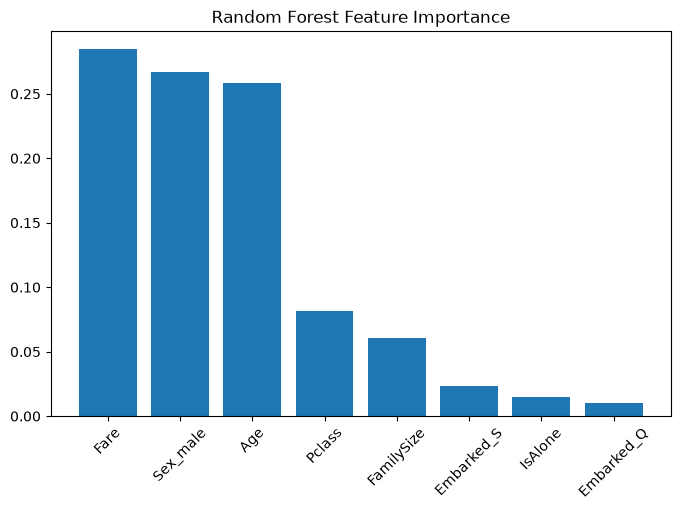

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_rf["Feature"][:10],
    importance_rf["Importance"][:10]
)

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.show()

In [14]:
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

importance_xgb.head(10)

,Feature,Importance
5,Sex_male,0.551230
0,Pclass,0.255245
3,FamilySize,0.056797
1,Age,0.038541
2,Fare,0.037937
7,Embarked_S,0.037334
6,Embarked_Q,0.022916
4,IsAlone,0.000000


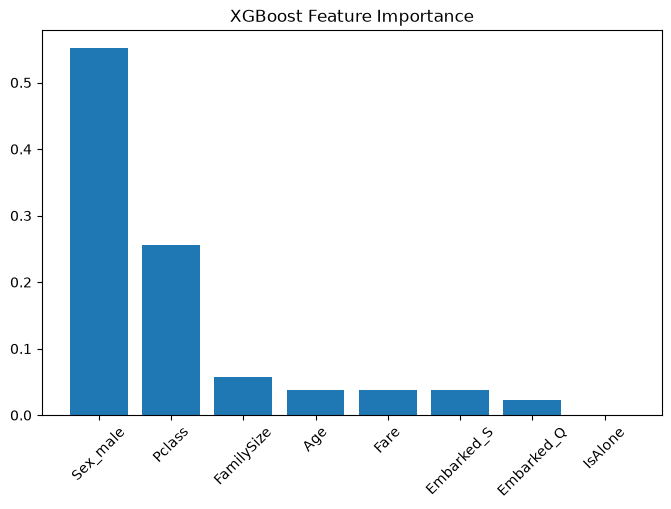

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_xgb["Feature"][:10],
    importance_xgb["Importance"][:10]
)

plt.xticks(rotation=45)

plt.title("XGBoost Feature Importance")

plt.show()

## Random Forest vs XGBoost

Random Forest builds many decision trees independently and combines their predictions through voting. XGBoost builds trees sequentially, where each new tree learns from the mistakes of the previous trees. Because of this boosting approach, XGBoost often achieves higher accuracy but usually requires more computation. Random Forest is generally simpler, faster to train, and less sensitive to hyperparameter tuning.